In [255]:
import numpy as np
from scipy import signal as sg
import soundfile as sf
import matplotlib
from matplotlib import pyplot as plt

In [256]:
song_stereo = (sf.read(file="untitled_excerpt.wav")[0])
song = (song_stereo[:, 0] + song_stereo[:, 1]) / 2
print(song)

SAMPLE_RATE = 48000
print(len(song))

segment = song[:222222]

[ 0.00000000e+00  1.06811523e-04  1.98364258e-04 ... -1.52587891e-05
  1.52587891e-05 -1.52587891e-05]
948000


Saved waveform.png


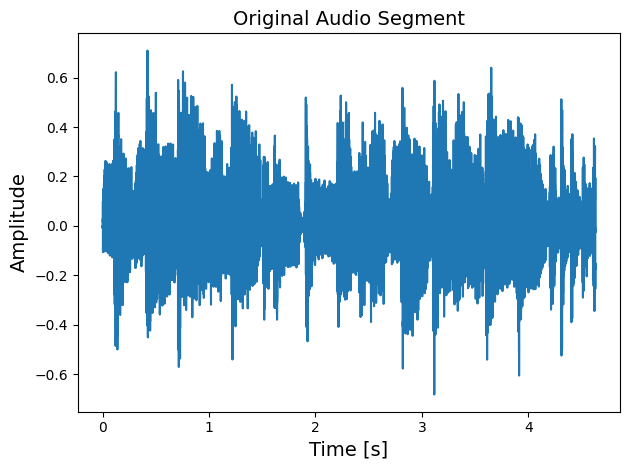

In [257]:
# Song visualization

figure = plt.figure()
ax = figure.add_subplot(1, 1, 1)
ax.set_title(r'Original Audio Segment', fontsize=14)

ax.set_xlabel(r'Time [s]', fontsize=14)

ax.set_ylabel('Amplitude', fontsize=14)

ax.plot(np.linspace(0, len(segment) / SAMPLE_RATE, len(segment)), segment)

plt.tight_layout()
plt.savefig('waveform.png', dpi=150, bbox_inches='tight')
print("Saved waveform.png")

Saved psd.png


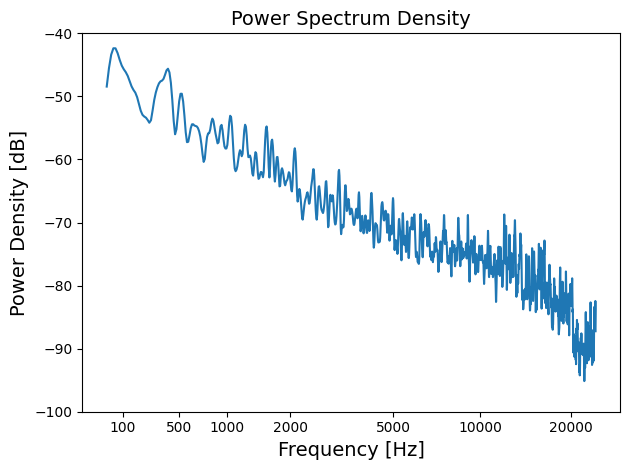

In [258]:
# Get power via welch's method
power_freqs, power_vals = sg.welch(segment, fs=SAMPLE_RATE, nperseg=2048, noverlap=1024, nfft=4096, window="blackmanharris")
power_vals_db = 10 * np.log10(power_vals)

# Perceptual frequency axis transformation (more convenient than pure log scale for audio analysis)
def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)

mel_freqs = hz_to_mel(power_freqs[1:SAMPLE_RATE // 2])

# Power visualization
figure = plt.figure()
ax = figure.add_subplot(1, 1, 1)
ax.set_title(r'Power Spectrum Density', fontsize=14)

ax.set_xlabel(r'Frequency [Hz]', fontsize=14)

# Manually set ticks at meaningful Hz values, converted to mel
tick_hz = [100, 500, 1000, 2000, 5000, 10000, 20000]
ax.set_xticks([hz_to_mel(f) for f in tick_hz])
ax.set_xticklabels([str(f) for f in tick_hz])

ax.set_ylabel(r'Power Density [dB]', fontsize=14)
ax.set_ylim(-100, -40)

ax.plot(mel_freqs, power_vals_db[1:])

plt.tight_layout()
plt.savefig('psd.png', dpi=150, bbox_inches='tight')
print("Saved psd.png")

In [259]:
fL = 390
fH = 3030

ws=[350, 3500]

gpass = 0.05
gstop = 40


print("in rads:", fL * 2 * np.pi / SAMPLE_RATE, fH * 2 * np.pi / SAMPLE_RATE)

bp_ord, wn = sg.cheb2ord(wp=[fL, fH], ws=ws, gpass=gpass, gstop=gstop, fs=SAMPLE_RATE, analog=False)
bp_sos = sg.cheby2(N=bp_ord, rs=gstop, Wn=wn, btype='bandpass', output='sos', fs=SAMPLE_RATE, analog=False)
bp_z, bp_p, bp_k = sg.cheby2(N=bp_ord, rs=gstop, Wn=wn, btype='bandpass', output='zpk', fs=SAMPLE_RATE, analog=False)
bp_b, bp_a = sg.sos2tf(bp_sos)

print(bp_ord)

in rads: 0.051050880620834134 0.3966260725157114
15


Saved pole_zero.png


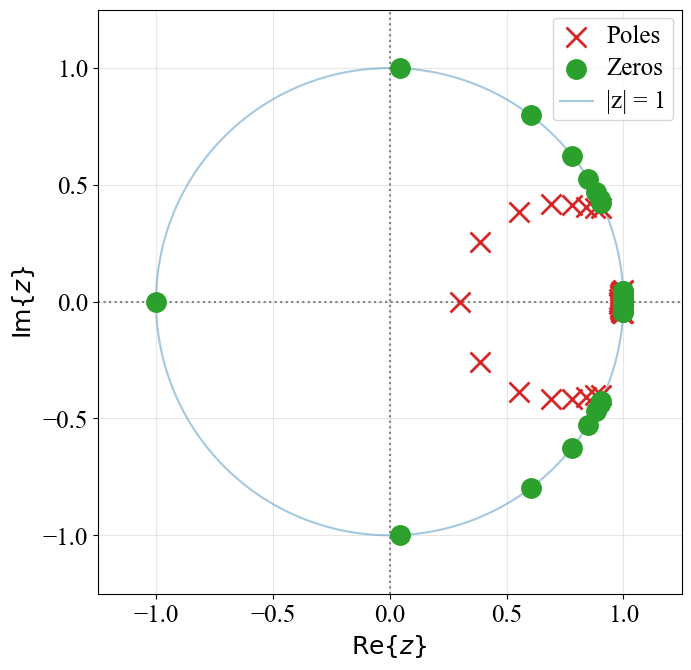

In [260]:
# Pole-Zero plot
GOLDEN_RATIO = (1 + 5**0.5) / 2
FIGURE_WIDTH = 10
FIGURE_HEIGHT = FIGURE_WIDTH / GOLDEN_RATIO
def format_figure_text(figure=None, font_size=None, font_name='Times New Roman'):
    if not figure:
        figure = plt.gcf()
    textHandles = [h for h in figure.findobj() if type(h) == matplotlib.text.Text]
    for th in textHandles:
        if font_name:
            th.set_fontname(font_name)
        if font_size:
            th.set_fontsize(font_size)

figure = plt.figure(figsize=(FIGURE_WIDTH * 0.7, FIGURE_WIDTH * 0.7))
axes = figure.add_subplot(1, 1, 1)
# Origin reference lines
axes.axhline(0, color='gray', lw=1.5, linestyle=':')
axes.axvline(0, color='gray', lw=1.5, linestyle=':')
# Poles
axes.plot(np.real(bp_p), np.imag(bp_p), 'x', color='C3', ms=15, mew=2, label='Poles', zorder=3, alpha=1)
# Zeros
axes.plot(np.real(bp_z), np.imag(bp_z), 'o', color='C2', ms=14, label='Zeros', zorder=3, alpha=1)
# Unit circle for reference
theta = np.linspace(0, 2 * np.pi, 400)
r = 1
axes.plot(r * np.cos(theta), r * np.sin(theta), color='C0', lw=1.5, alpha=0.4, label=r'|z| = 1')
axes.set_xlim(-1.25, 1.25)
axes.set_ylim(-1.25, 1.25)
axes.set_xlabel(r'$\mathrm{Re}\{z\}$', fontsize=14)
axes.set_ylabel(r'$\mathrm{Im}\{z\}$', fontsize=14)
axes.legend(fontsize=12)
axes.grid(True, alpha=0.3)
axes.set_aspect('equal')
format_figure_text(figure=figure, font_size=18)
plt.tight_layout()
plt.savefig('pole_zero.png', dpi=150, bbox_inches='tight')
print("Saved pole_zero.png")

C:\Users\aidan\AppData\Local\Temp\ipykernel_16108\2624645306.py:3: RuntimeWarning: divide by zero encountered in log10
  h_dB = 20 * np.log10(np.abs(h))


Saved mag.png


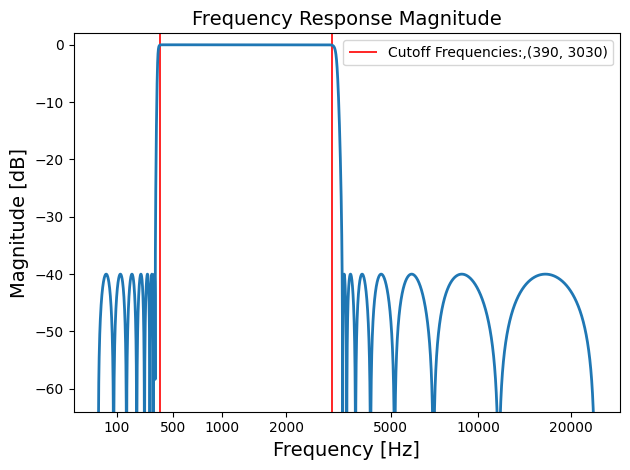

In [261]:
w, h = sg.freqz_sos(bp_sos, worN=np.linspace(0, SAMPLE_RATE // 2, SAMPLE_RATE // 2), fs=SAMPLE_RATE)
w_mel = hz_to_mel(w)
h_dB = 20 * np.log10(np.abs(h))

# Magnitude visualization
figure = plt.figure()
ax = figure.add_subplot(1, 1, 1)
ax.set_title(r'Frequency Response Magnitude', fontsize=14)

ax.set_xlabel(r'Frequency [Hz]', fontsize=14)

# Manually set ticks at meaningful Hz values, converted to mel
tick_hz = [100, 500, 1000, 2000, 5000, 10000, 20000]
ax.set_xticks([hz_to_mel(f) for f in tick_hz])
ax.set_xticklabels([str(f) for f in tick_hz])

ax.set_ylabel(r'Magnitude [dB]', fontsize=14)
ax.set_ylim(-64, 2)

ax.vlines([hz_to_mel(fL), hz_to_mel(fH)], ymin=-64, ymax=2, color='red', lw=1.2, zorder=0, label=r'Cutoff Frequencies:,' f'{fL, fH}')

ax.plot(w_mel, h_dB, lw=2, zorder=1)

plt.legend()
plt.tight_layout()
plt.savefig('mag.png', dpi=150, bbox_inches='tight')
print("Saved mag.png")

Saved phase.png


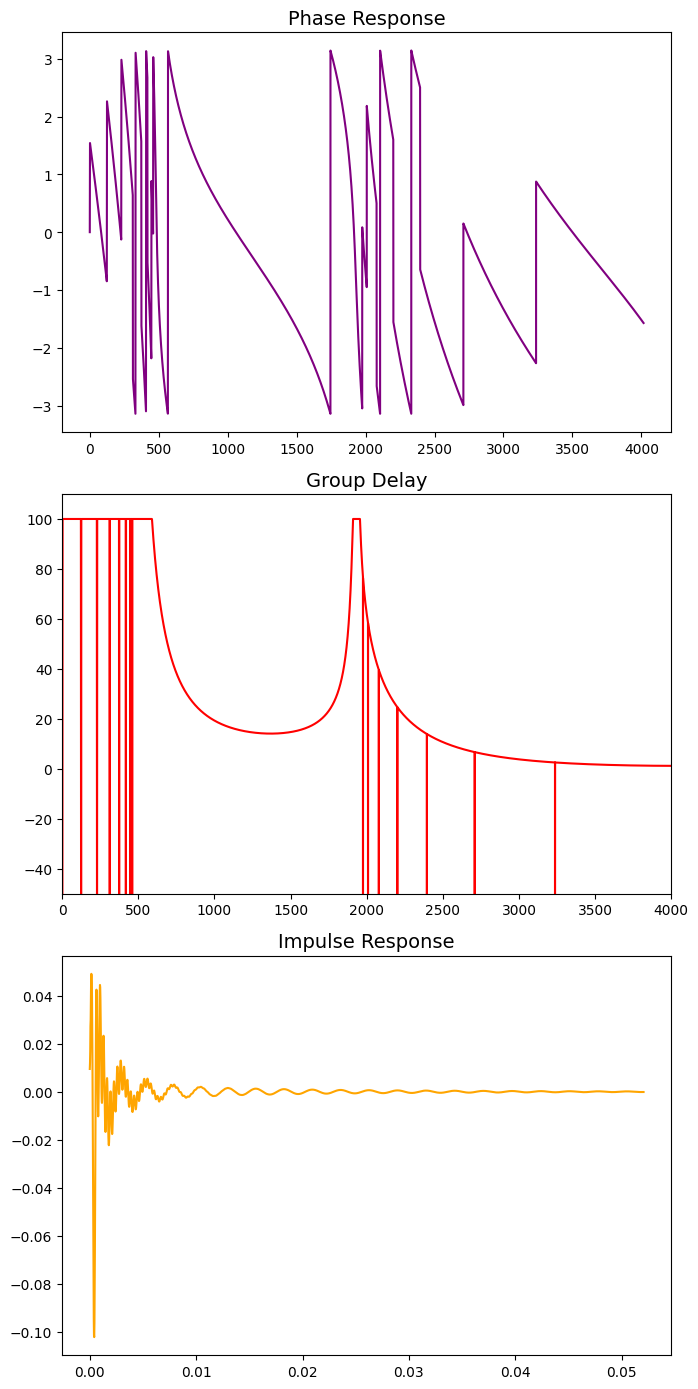

In [262]:
phase = np.angle(h)
phase_unwrapped = np.unwrap(phase)
dw = (np.pi) / len(phase_unwrapped)
gd_diff = -np.diff(phase_unwrapped) / dw
w_gd_mel = hz_to_mel(w[:-1])


gd_max = 100
for i in range(len(gd_diff)):
    if np.abs(gd_diff[i]) > gd_max:
        if gd_diff[i] > 0:
            gd_diff[i] = gd_max
        else:
            gd_diff[i] = -gd_max


impulse = np.zeros(2500)
impulse[0] = 1
ir = sg.sosfilt(bp_sos, impulse)
t = np.arange(2500) / SAMPLE_RATE

# Phase, group delay, and impulse response visualization
figure = plt.figure(num=3, figsize=(FIGURE_WIDTH * 0.7, FIGURE_WIDTH * 0.7 * 2))
plt.subplots_adjust(hspace=5)
ax1 = figure.add_subplot(3, 1, 1)
ax1.set_title(r'Phase Response', fontsize=14)
ax1.plot(w_mel, phase, color='Purple')

ax2 = figure.add_subplot(3, 1, 2)
ax2.set_title(r'Group Delay', fontsize=14)
ax2.plot(w_mel[1:], gd_diff, color='Red')
ax2.set_ylim(-gd_max / 2, 1.1 * gd_max)
ax2.set_xlim(0, 4000)

ax2 = figure.add_subplot(3, 1, 3)
ax2.set_title(r'Impulse Response', fontsize=14)
ax2.plot(t, ir, color='Orange')

plt.tight_layout()
plt.savefig('phase.png', dpi=250, bbox_inches='tight')
print("Saved phase.png")

In [263]:
sf.write(file='untitled_excerpt_bp.wav', data=sg.sosfilt(bp_sos, song), samplerate=48000)

In [264]:
segment_bp = sg.sosfilt(bp_sos, segment)

Saved psd_overlap.png


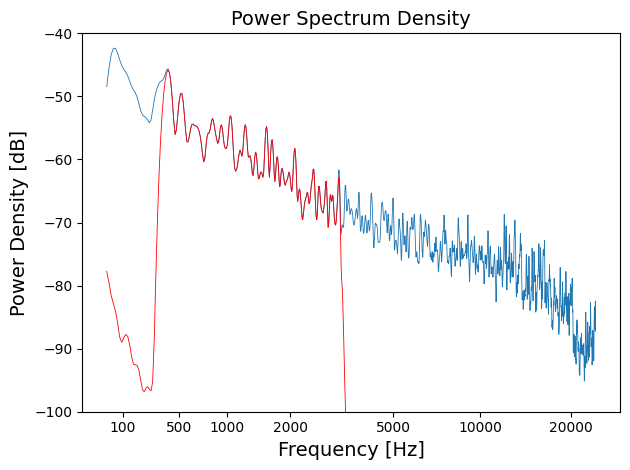

In [265]:
# Get power via welch's method
power_freqs_bp, power_vals_bp = sg.welch(segment_bp, fs=SAMPLE_RATE, nperseg=2048, noverlap=1024, nfft=4096, window="blackmanharris")
power_vals_bp_db = 10 * np.log10(power_vals_bp)

# Perceptual frequency axis transformation (more convenient than pure log scale for audio analysis)
def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)

mel_freqs_bp = hz_to_mel(power_freqs_bp[1:SAMPLE_RATE // 2])

# Power visualization
figure = plt.figure()
ax = figure.add_subplot(1, 1, 1)
ax.set_title(r'Power Spectrum Density', fontsize=14)

ax.set_xlabel(r'Frequency [Hz]', fontsize=14)

# Manually set ticks at meaningful Hz values, converted to mel
tick_hz = [100, 500, 1000, 2000, 5000, 10000, 20000]
ax.set_xticks([hz_to_mel(f) for f in tick_hz])
ax.set_xticklabels([str(f) for f in tick_hz])

ax.set_ylabel(r'Power Density [dB]', fontsize=14)
ax.set_ylim(-100, -40)

ax.plot(mel_freqs, power_vals_db[1:], lw=0.6)
ax.plot(mel_freqs_bp, power_vals_bp_db[1:], lw=0.6, color='red')

plt.tight_layout()
plt.savefig('psd_overlap.png', dpi=250, bbox_inches='tight')
print("Saved psd_overlap.png")

In [266]:
fL_1 = 50
ws_1=[44, 3500]
fL_2 = 200
ws_2=[178, 3500]
fL_3 = 500
ws_3=[455, 3500]
fL_4 = 1500
ws_4=[1430, 3500]

bp_ord_1, wn_1 = sg.cheb2ord(wp=[fL_1, fH], ws=ws_1, gpass=gpass, gstop=gstop, fs=SAMPLE_RATE, analog=False)
bp_sos_1 = sg.cheby2(N=bp_ord_1, rs=gstop, Wn=wn_1, btype='bandpass', output='sos', fs=SAMPLE_RATE, analog=False)
bp_ord_2, wn_2 = sg.cheb2ord(wp=[fL_2, fH], ws=ws_2, gpass=gpass, gstop=gstop, fs=SAMPLE_RATE, analog=False)
bp_sos_2 = sg.cheby2(N=bp_ord_2, rs=gstop, Wn=wn_2, btype='bandpass', output='sos', fs=SAMPLE_RATE, analog=False)
bp_ord_3, wn_3 = sg.cheb2ord(wp=[fL_3, fH], ws=ws_3, gpass=gpass, gstop=gstop, fs=SAMPLE_RATE, analog=False)
bp_sos_3 = sg.cheby2(N=bp_ord_3, rs=gstop, Wn=wn_3, btype='bandpass', output='sos', fs=SAMPLE_RATE, analog=False)
bp_ord_4, wn_4 = sg.cheb2ord(wp=[fL_4, fH], ws=ws_4, gpass=gpass, gstop=gstop, fs=SAMPLE_RATE, analog=False)
bp_sos_4 = sg.cheby2(N=bp_ord_4, rs=gstop, Wn=wn_4, btype='bandpass', output='sos', fs=SAMPLE_RATE, analog=False)

print(bp_ord_1, bp_ord_2, bp_ord_3, bp_ord_4)

15 15 15 15


In [267]:
sf.write(file='untitled_excerpt_bp_fL_1.wav', data=sg.sosfilt(bp_sos_1, song), samplerate=48000)
sf.write(file='untitled_excerpt_bp_fL_2.wav', data=sg.sosfilt(bp_sos_2, song), samplerate=48000)
sf.write(file='untitled_excerpt_bp_fL_3.wav', data=sg.sosfilt(bp_sos_3, song), samplerate=48000)
sf.write(file='untitled_excerpt_bp_fL_4.wav', data=sg.sosfilt(bp_sos_4, song), samplerate=48000)

In [268]:
fH_1 = 18000
ws_1=[345, 20000]
fH_2 = 10000
ws_2=[345, 11000]
fH_3 = 5000
ws_3=[350, 5550]
fH_4 = 1500
ws_4=[350, 1630]

bp_ord_1, wn_1 = sg.cheb2ord(wp=[fL, fH_1], ws=ws_1, gpass=gpass, gstop=gstop, fs=SAMPLE_RATE, analog=False)
bp_ord_2, wn_2 = sg.cheb2ord(wp=[fL, fH_2], ws=ws_2, gpass=gpass, gstop=gstop, fs=SAMPLE_RATE, analog=False)
bp_ord_3, wn_3 = sg.cheb2ord(wp=[fL, fH_3], ws=ws_3, gpass=gpass, gstop=gstop, fs=SAMPLE_RATE, analog=False)
bp_ord_4, wn_4 = sg.cheb2ord(wp=[fL, fH_4], ws=ws_4, gpass=gpass, gstop=gstop, fs=SAMPLE_RATE, analog=False)

print(bp_ord_1, bp_ord_2, bp_ord_3, bp_ord_4)

bp_sos_1 = sg.cheby2(N=bp_ord_1, rs=gstop, Wn=wn_1, btype='bandpass', output='sos', fs=SAMPLE_RATE, analog=False)
bp_sos_2 = sg.cheby2(N=bp_ord_2, rs=gstop, Wn=wn_2, btype='bandpass', output='sos', fs=SAMPLE_RATE, analog=False)
bp_sos_3 = sg.cheby2(N=bp_ord_3, rs=gstop, Wn=wn_3, btype='bandpass', output='sos', fs=SAMPLE_RATE, analog=False)
bp_sos_4 = sg.cheby2(N=bp_ord_4, rs=gstop, Wn=wn_4, btype='bandpass', output='sos', fs=SAMPLE_RATE, analog=False)

sf.write(file='untitled_excerpt_bp_fH_1.wav', data=sg.sosfilt(bp_sos_1, song), samplerate=48000)
sf.write(file='untitled_excerpt_bp_fH_2.wav', data=sg.sosfilt(bp_sos_2, song), samplerate=48000)
sf.write(file='untitled_excerpt_bp_fH_3.wav', data=sg.sosfilt(bp_sos_3, song), samplerate=48000)
sf.write(file='untitled_excerpt_bp_fH_4.wav', data=sg.sosfilt(bp_sos_4, song), samplerate=48000)

15 15 15 15


In [269]:
# Delay filter specification

NUM_TAPS = 15                           # Number of previous samples to consider when calculating current
TAP_SPACING = int(SAMPLE_RATE * 1.0)    # Delay in terms of seconds
ATTENUATION_CONSTANT = 0.5              # Amount that delay amplitude increases each iteration
DRY_WET = 0.5                           # 1 = fully wet, 0 = fully dry

bp_spec = []
bp_sos = []
for i in range(NUM_TAPS):
    wp=[min(100 + 20 * (i + 1), 800), max(4000 - (i * 400), 1000)]
    ws=[min(50 + 15 * (i + 1), 600), max(8000 - (i * 800), 1500)]
    #print(wp, ws)
    bp_spec.append(sg.cheb2ord(wp=wp, ws=ws, gpass=gpass, gstop=gstop, fs=SAMPLE_RATE, analog=False))
    bp_sos.append(sg.cheby2(N=bp_spec[i][0], rs=gstop, Wn=bp_spec[i][1], btype='bandpass', output='sos', fs=SAMPLE_RATE, analog=False))

# Impulse train with attenuation and filtering
delay_ir = np.zeros(NUM_TAPS * TAP_SPACING)
for i in range(NUM_TAPS):
    tap = np.zeros(NUM_TAPS * TAP_SPACING)
    tap[i * TAP_SPACING] = ATTENUATION_CONSTANT ** (i + 1)
    tap = sg.sosfilt(bp_sos[i], tap)
    delay_ir += tap

# Apply delay
song_delay = sg.convolve(song, delay_ir, mode='full')

# Get the transfer function
def transfer_function(h, z):
    H = 0
    for n in range(len(h)):
        H += h[n] * (z ** (-n))
    return H

print(transfer_function(delay_ir, np.e**(0j)), transfer_function(delay_ir, np.e**(1j)), transfer_function(delay_ir, np.e*(2j)))

# Normalize to song volume and length
song_delay = np.multiply(song_delay, (max(song) / max(song_delay[:len(song) - 1])))

song_delay_dw = np.zeros(len(song) + len(delay_ir))
song_delay_dw[:len(song)] = song * (1 - DRY_WET) + song_delay[:len(song)] * (DRY_WET)
song_delay_dw[len(song) + 1:] = song_delay[len(song):] * (DRY_WET)

sf.write(file='untitled_excerpt_delay.wav', data=song_delay_dw, samplerate=48000)

(2.1362300078294753e-06+0j) (-0.00012103950201263385+0.0011981974509236173j) (0.007527557248802544-0.0033014864621178546j)


C:\Users\aidan\AppData\Local\Temp\ipykernel_16108\3296632634.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Saved delay_ir.png


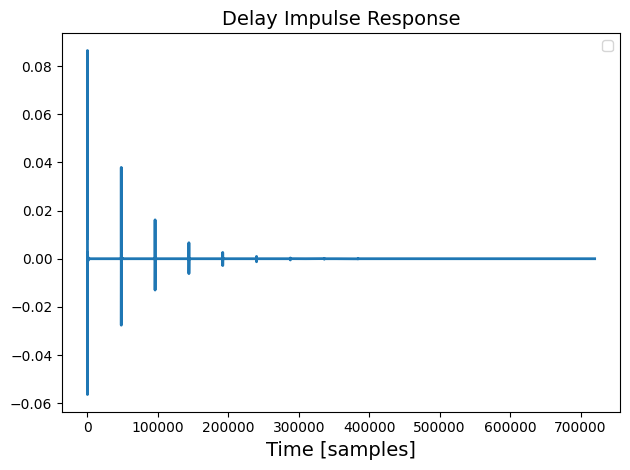

In [270]:
# Delay IR visualization
figure = plt.figure()
ax = figure.add_subplot(1, 1, 1)
ax.set_title(r'Delay Impulse Response', fontsize=14)

ax.set_xlabel(r'Time [samples]', fontsize=14)

ax.plot(np.linspace(0, len(delay_ir), len(delay_ir)), delay_ir, lw=2, zorder=1)

plt.legend()
plt.tight_layout()
plt.savefig('delay_ir.png', dpi=150, bbox_inches='tight')
print("Saved delay_ir.png")

C:\Users\aidan\AppData\Local\Temp\ipykernel_16108\1156779134.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Saved delay_ir_zoom.png


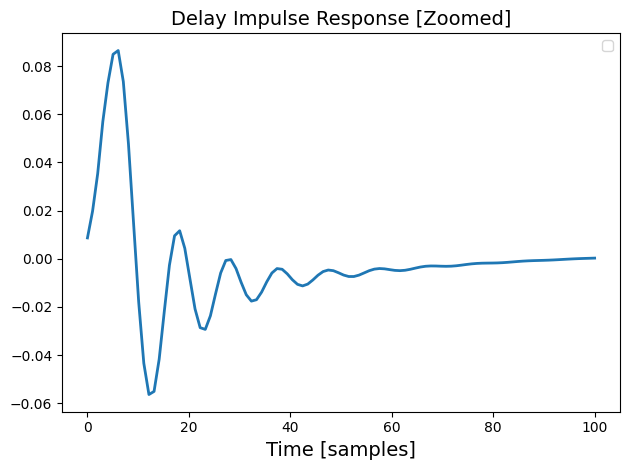

In [271]:
# Delay IR visualization
figure = plt.figure()
ax = figure.add_subplot(1, 1, 1)
ax.set_title(r'Delay Impulse Response [Zoomed]', fontsize=14)

ax.set_xlabel(r'Time [samples]', fontsize=14)

ax.plot(np.linspace(0, 100, 100), delay_ir[:100], lw=2, zorder=1)

plt.legend()
plt.tight_layout()
plt.savefig('delay_ir_zoom.png', dpi=150, bbox_inches='tight')
print("Saved delay_ir_zoom.png")

In [272]:
w = np.linspace(0, 20000, 5000)
H = []
for f in range(len(w)):
    H.append(transfer_function(ir, np.e**(f * 1j)))

C:\Users\aidan\AppData\Local\Temp\ipykernel_16108\3479168575.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Saved delay_mag_phase.png


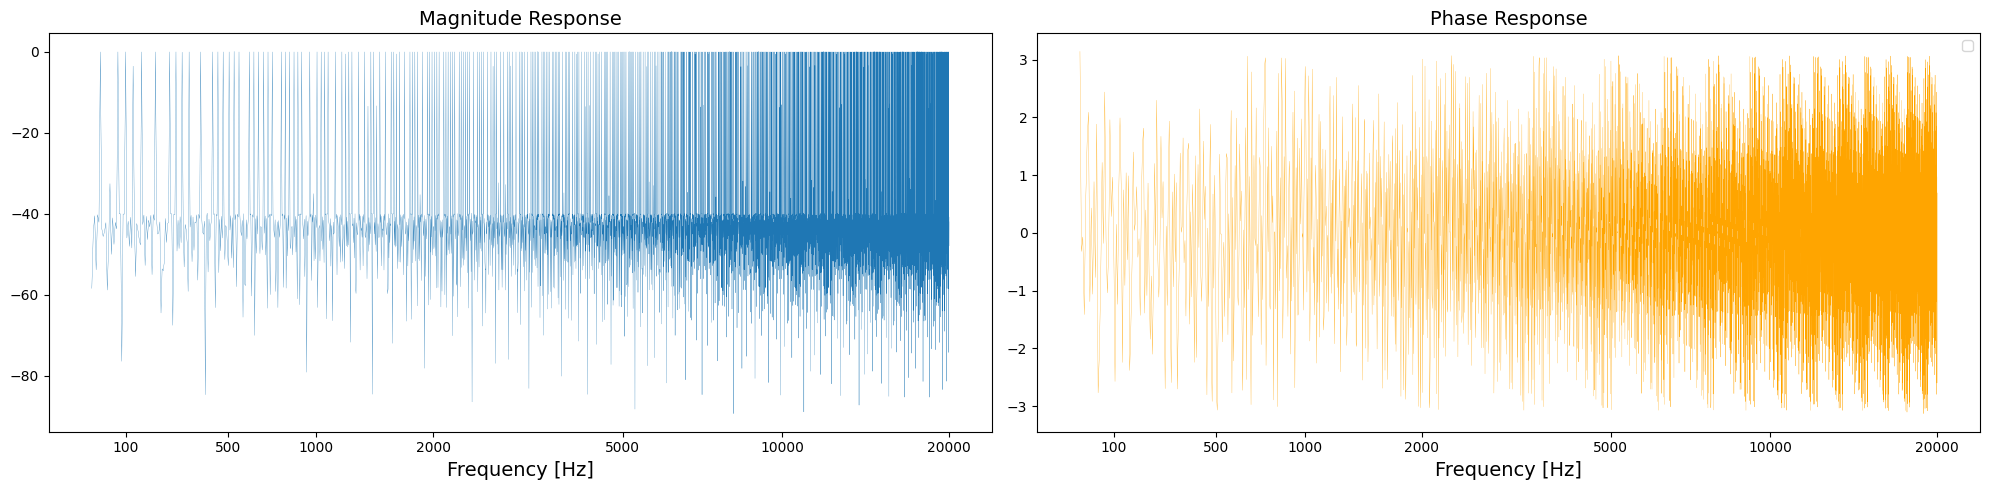

In [282]:
w_mel = hz_to_mel(w)
H_dB = 20 * np.log10(np.abs(H))
phase = np.angle(H)
group_delay = -np.diff(np.unwrap(phase)) / np.diff(w)

# Delay IR visualization
figure = plt.figure(num=2, figsize=[20, 5])
ax1 = figure.add_subplot(1, 2, 1)
ax1.set_title(r'Magnitude Response', fontsize=14)
ax1.set_xlabel(r'Frequency [Hz]', fontsize=14)
ax1.plot(w_mel, H_dB, lw=0.2)
tick_hz = [100, 500, 1000, 2000, 5000, 10000, 20000]
ax1.set_xticks([hz_to_mel(f) for f in tick_hz])
ax1.set_xticklabels([str(f) for f in tick_hz])

ax2 = figure.add_subplot(1, 2, 2)
ax2.set_title(r'Phase Response', fontsize=14)
ax2.set_xlabel(r'Frequency [Hz]', fontsize=14)
ax2.plot(w_mel, phase, lw=0.2, color='orange')
tick_hz = [100, 500, 1000, 2000, 5000, 10000, 20000]
ax2.set_xticks([hz_to_mel(f) for f in tick_hz])
ax2.set_xticklabels([str(f) for f in tick_hz])

plt.legend()
plt.tight_layout()
plt.savefig('delay_mag_phase.png', dpi=250, bbox_inches='tight')
print("Saved delay_mag_phase.png")

In [287]:
NUM_TAPS = 1
TAP_SPACING = SAMPLE_RATE
ATTENUATION_CONSTANT = 1

# Impulse train with attenuation and filtering
delay_ir = np.zeros(NUM_TAPS * TAP_SPACING)
for i in range(NUM_TAPS):
    tap = np.zeros(NUM_TAPS * TAP_SPACING)
    tap[i * TAP_SPACING] = ATTENUATION_CONSTANT ** (i + 1)
    delay_ir += tap

w = np.linspace(0, 20000, 5000)
H = []
for f in range(len(w)):
    H.append(transfer_function(ir, np.e**(f * 1j)))

C:\Users\aidan\AppData\Local\Temp\ipykernel_16108\3592468183.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Saved simple_delay_mag_phase.png


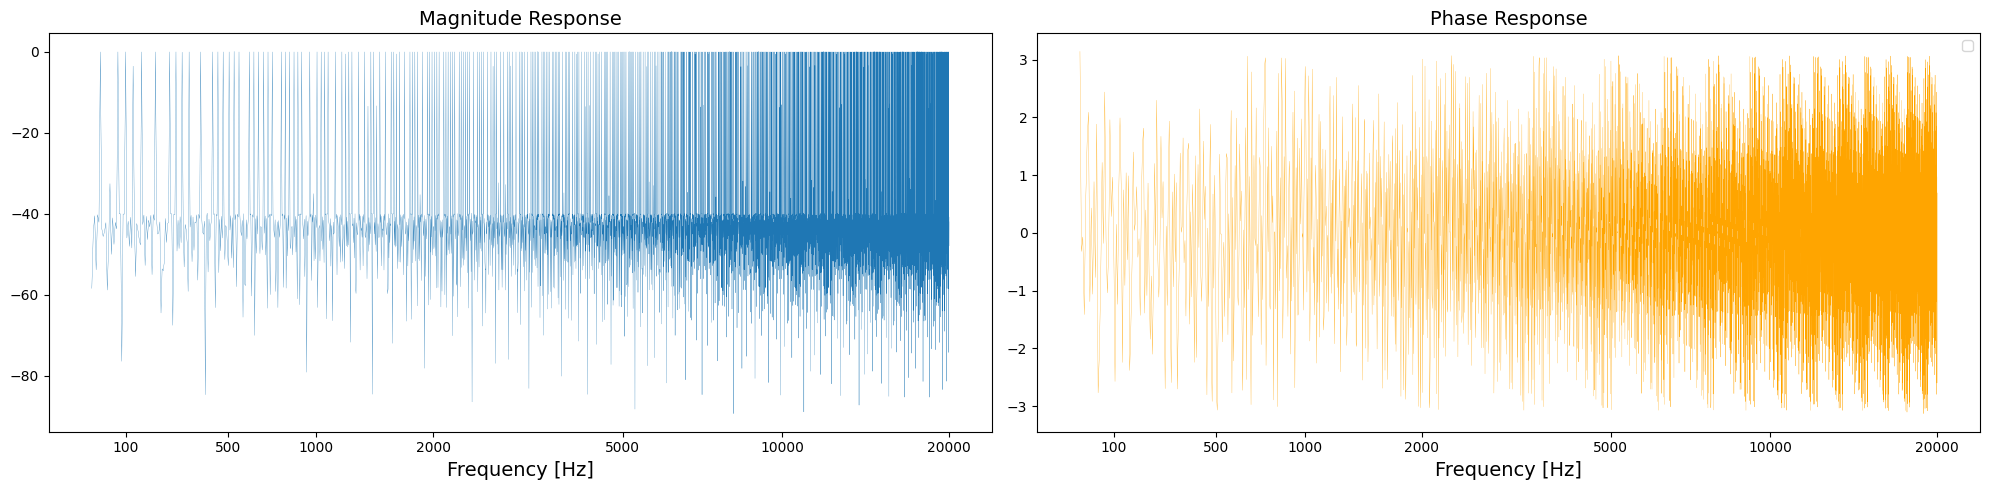

In [288]:
w_mel = hz_to_mel(w)
H_dB = 20 * np.log10(np.abs(H))
phase = np.angle(H)
group_delay = -np.diff(np.unwrap(phase)) / np.diff(w)

# Delay IR visualization
figure = plt.figure(num=2, figsize=[20, 5])
ax1 = figure.add_subplot(1, 2, 1)
ax1.set_title(r'Magnitude Response', fontsize=14)
ax1.set_xlabel(r'Frequency [Hz]', fontsize=14)
ax1.plot(w_mel, H_dB, lw=0.2)
tick_hz = [100, 500, 1000, 2000, 5000, 10000, 20000]
ax1.set_xticks([hz_to_mel(f) for f in tick_hz])
ax1.set_xticklabels([str(f) for f in tick_hz])

ax2 = figure.add_subplot(1, 2, 2)
ax2.set_title(r'Phase Response', fontsize=14)
ax2.set_xlabel(r'Frequency [Hz]', fontsize=14)
ax2.plot(w_mel, phase, lw=0.2, color='orange')
tick_hz = [100, 500, 1000, 2000, 5000, 10000, 20000]
ax2.set_xticks([hz_to_mel(f) for f in tick_hz])
ax2.set_xticklabels([str(f) for f in tick_hz])

plt.legend()
plt.tight_layout()
plt.savefig('simple_delay_mag_phase.png', dpi=250, bbox_inches='tight')
print("Saved simple_delay_mag_phase.png")